In [452]:
import numpy as np
from sympy import sin, cos 
import sympy as sp
import scipy as scp
import pandas as pd
from cmath import *
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scienceplots
plt.style.context(['science'])
plt.rcParams['text.usetex'] = True
plt.rcParams["font.family"] = "Times New Roman"
import pickle
import timeit
import glob # need to merge arrays
import os # need to make directory
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.stats import chi2
import ast
import ternary

print("Version", ternary.__version__)

t0 = timeit.default_timer()

Version 1.0.8


In [2]:
def ini_composition_norm(x):
    arr = np.asarray(x, dtype=float)
    s = arr.sum()
    if s == 0:
        raise ValueError("Cannot normalize: sum of elements is zero.")
    return arr / s

In [3]:
ini_composition_norm([1,2,0]), ini_composition_norm([1,1,0])

(array([0.33333333, 0.66666667, 0.        ]), array([0.5, 0.5, 0. ]))

## construct prob avg matrix

In [4]:
from scipy.special import sph_harm

### eq 6, 2503.15468
def H_LIV_paper(E,theta,phi,d,a_eff=None,c_eff=None):
    """
    Compute H_LIV_paper^(d) in flavor space.

    Parameters
    ----------
    E : float
        Neutrino energy
    theta, phi : float
        Direction of momentum (polar, azimuth)
    d : int
        Operator dimension
    a_eff, c_eff : dict
        LIV coefficients indexed as:
        coeff[(l, m)] -> 3x3 complex matrix in flavor space

    Returns
    -------
    H : (3,3) complex ndarray
        LIV Hamiltonian in flavor space
    """
    d = int(d)
    H = np.zeros((3, 3), dtype=complex)

    prefactor = E**(d - 3)
#     print(f"prefactor={prefactor}")
    for l in range(d):
        for m in range(-l, l + 1):

            Ylm = 1 # sph_harm(m, l, phi, theta)

            if d % 2 == 1:  # CPT-odd
                if a_eff is None or (l, m) not in a_eff:
#                     print(f'a nai...(l,m)={(l,m)}')
                    continue
#                 print(f'a ache {prefactor} * {a_eff[(l, m)]}')
                H += prefactor * Ylm * a_eff[(l, m)]

            else:  # CPT-even
                if c_eff is None or (l, m) not in c_eff:
                    continue
                H -= prefactor * Ylm * c_eff[(l, m)]

    return H + H.conj().T

In [77]:
def pmns_matrix(theta12, theta23, theta13, delta):

    s12, s13, s23 = np.sin(theta12), np.sin(theta13), np.sin(theta23)
    c12, c13, c23 = np.cos(theta12), np.cos(theta13), np.cos(theta23)

    return np.array([
        [c12*c13, s12*c13, s13*np.exp(-1j*delta)],
        [-s12*c23 - c12*s23*s13*np.exp(1j*delta),
         c12*c23 - s12*s23*s13*np.exp(1j*delta),
         s23*c13],
        [s12*s23 - c12*c23*s13*np.exp(1j*delta),
         -c12*s23 - s12*c23*s13*np.exp(1j*delta),
         c23*c13]
    ], dtype=complex)

def H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta):
    """Vacuum Hamiltonian in flavor basis."""
    U_pmns = pmns_matrix(theta12, theta23, theta13, delta)
    H0 = U_pmns @ np.diag([0, dm21/(2*E), dm31/(2*E)]) @ U_pmns.conj().T
    return H0 

def prob_avg(E, dm21, dm31, theta12, theta23, theta13, delta,
            theta, phi, d, a_eff=None, c_eff=None):

    H0 = H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta)
    HLIV = H_LIV_paper(E, theta, phi, d, a_eff=a_eff, c_eff=c_eff)
    Htot = H0 + HLIV
    rescaled_Htot = Htot
#     rescaled_Htot = Htot / np.max(np.abs(Htot)) 
    ## orders of magnitude mismatch of elements in H0 & HLIV
    ## can give error to eigenvector calculation
    ## hence rescaling the matrix, keeping the egvectors same
    _, evecs = np.linalg.eigh(rescaled_Htot)
    V = evecs

    avgP = np.zeros((3,3))
    for alpha in range(3):
        for beta in range(3):
            avgP[alpha, beta] = np.sum(np.abs(V[alpha, :])**2 * np.abs(V[beta, :])**2)

    return avgP 

In [7]:
Emax_list = np.logspace(4, 8, 6)   # change number of points if needed

tot = 0
for im, E in enumerate(Emax_list):

    for alpha in range(3):
        for beta in range(alpha,3):
            
            offdiag_pairs = [(0, 1), (1, 2), (0, 2)]
            for p, q in offdiag_pairs:
                if (p, q) != (alpha, beta):

                    for cxfactor in np.logspace(-45, 45, 80):
                        tot+=1

tot, len(Emax_list)* 15 * 80

(7200, 7200)

In [8]:
36*80

2880

In [10]:
Emax_list = np.logspace(4, 8, 6)   # change number of points if needed
Emin = 1.0

# storage
eratio  = []
muratio = []
tauratio = []
delta=0

dm21, dm31 = np.array([7.49e-5, 2.534e-3])*1e-18
theta = np.pi / 3 # polar angle
phi = np.pi / 4   # azimuthal angle

for d in range(3,8):
    print('d=',d)
    s=0
    tot = 0
    
    for im, E in enumerate(Emax_list):

        for alpha in range(3):
            for beta in range(alpha,3):
                theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                                              np.arcsin(np.sqrt(0.02225)), 
                                              np.arcsin(np.sqrt(0.572))]

                delta = 197*np.pi/180

                for cxfactor in np.logspace(-45, 45, 80):
                    c_eff = {}
                    # initialize (l=2, m=2) coefficient matrix
                    c_22 = np.zeros((3, 3), dtype=complex)
                    # flavor indices: e=0, mu=1, tau=2
    #                 c_22[2,2] = np.random.uniform(0, 1) * cxfactor*1e-36  # GeV^{-2}
                    c_22[alpha, beta] = cxfactor*1e-36  # GeV^{-2}

    #                 if we want two nonzero LIV
                    offdiag_pairs = [(0, 1), (1, 2), (0, 2)]
                    # pick a pair different from (alpha, beta)
                    for p, q in offdiag_pairs:
                        if (p, q) != (alpha, beta):
                            c_22[p, q] = np.random.uniform(0, 1) * cxfactor * 1e-36  # GeV^{-2}
                            tot+=1
                            break

#     print(d, tot)
# """


                    # store in coefficient dictionary
                    c_eff[(0, 0)] = c_22
                    a_eff = (c_eff)

                    prob_avg_matrix = prob_avg(E, dm21, dm31, 
                                theta12, theta23, theta13, delta,
                                theta, phi, d, a_eff, c_eff)

                    comp = (prob_avg_matrix 
                            @ ini_composition_norm([1,0,0]))[2]
    #                 comp = (prob_avg_matrix 
    #                         @ ini_composition_norm([1,0,0]))[2]
    
                    if comp>0.45:
                        s+=1
    #                     print("found one:")
#                         print((alpha, beta), (p,q))
    #                   print((alpha, beta), (p,q), cxfactor, comp)
    #                     print((alpha, beta), cxfactor, comp)
#####                 LIV vs H0
#                         arr = H_LIV_paper(E, theta, phi, d, a_eff, c_eff)/H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta)
#                         arr = arr.flatten()
#                         arr = arr[arr != 0]
    #                     print(np.log10(arr))

    #                     print(np.round(prob_avg_matrix,2))
#                         break

    print(s,tot)
        
# """        

d= 3
65 2880
d= 4
85 2880
d= 5
93 2880
d= 6
94 2880
d= 7
106 2880


## chi sqr 1 parameter

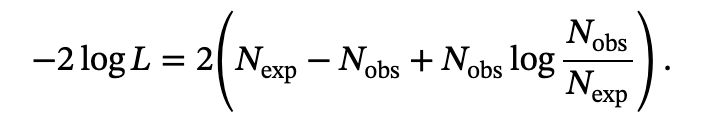

In [291]:
def chisq(diffBSM, diff0):
    if diffBSM==0 and diff0==0:
        return 0 
    if diffBSM==0 and diff0!=0:
        raise Exception("diffBSM is zero, diff0 is not!!")
        
    frac = diff0/diffBSM
    if diff0==0:
        frac=1
        
    return 2*(diffBSM - diff0 + diff0 * np.log(frac))

In [503]:
from scipy.optimize import brentq

def chisq(NBSM, N0):
    if NBSM == 0 and N0 == 0:
        return 0
    if NBSM == 0 and N0 != 0:
        raise Exception("NBSM is zero, N0 is not!!")

    frac = N0 / NBSM
    if N0 == 0:
        frac = 1  # avoid log(0)

    return 2 * (NBSM - N0 + N0 * np.log(frac))


N0 = 4168
target = 3.84

# Define function to solve f(x)=0
f = lambda x: chisq(x, N0) - target

# Find lower and upper roots
x_low = brentq(f, 3500, N0)     # search below 4000
x_high = brentq(f, N0, 4500)    # search above 4000

print("Lower solution:", x_low)
print("Upper solution:", x_high)
# Output (approx):
# Lower solution: 3877.34
# Upper solution: 4125.22

Lower solution: 4042.765405853057
Upper solution: 4295.794567941308


In [504]:
chisq(4060, 4175)

3.2270621546318523

In [12]:
neuflux = pd.read_csv("neuflux_1505.04020/neuflux_SFR_proton_only.csv", 
                      header=None, names=["log10Enu", "rate"]) 

E_eV = 10**neuflux["log10Enu"].values
rate = neuflux["rate"].values   # already GeV/(cm^2 s sr)")

# Build interpolation function: input E (eV) 
flux_interp = interp1d(
    E_eV,
    rate,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

In [13]:
poemma_area = pd.read_csv("eff_area/poemma_nutau_tau.csv", 
                      header=None, names=["log10Enu", "area"]) 

In [14]:
kmtocm = 1e5
E_eV = 10**poemma_area["log10Enu"].values
eff_area = poemma_area["area"].values * kmtocm**2   # cm^2 sr

poemma_area_interp = interp1d(
    E_eV,
    eff_area,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e17  # eV
print(f"area at E = {E_test:.1e} eV : {poemma_area_interp(E_test):.3e} cm^2 sr")

area at E = 1.0e+17 eV : 7.172e+08 cm^2 sr


In [15]:
def flavor_fraction(E, dm21, dm31, 
                  theta12, theta23, theta13, delta,
                  theta, phi, d=0, a_eff=None, c_eff=None,
                  src_ratio=[1,2,0], flavor='tau'):
    
    flavor_dict = {'e':0, 'mu':1, 'tau':2}

    prob_avg_matrix = prob_avg(E, dm21, dm31, 
                theta12, theta23, theta13, delta,
                theta, phi, d, a_eff, c_eff)

    comp = (prob_avg_matrix 
            @ ini_composition_norm(src_ratio))[flavor_dict[flavor]]

    return comp 

In [162]:
flavor_fraction(1e5, dm21, dm31, 
                  theta12, theta23, theta13, delta,
                  theta, phi, d=0, a_eff=None, c_eff=None,
                  src_ratio=[1,2,0], flavor='tau')

0.3424124916100521

In [515]:
def flavor_fraction_test(E, dm21, dm31, 
                  theta12, theta23, theta13, delta,
                  theta, phi, d=0, a_eff=None, c_eff=None,
                  src_ratio=[1,2,0], flavor='tau'):
    
    flavor_dict = {'e':0, 'mu':1, 'tau':2}

    H0 = H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta)
    HLIV = H_LIV_paper(E, theta, phi, d, a_eff=a_eff, c_eff=c_eff)
    Htot = H0 + HLIV
    rescaled_Htot = Htot
#     rescaled_Htot = Htot / np.max(np.abs(Htot)) 
    ## orders of magnitude mismatch of elements in H0 & HLIV
    ## can give error to eigenvector calculation
    ## hence rescaling the matrix, keeping the egvectors same
    _, evecs = np.linalg.eigh(rescaled_Htot)
    V = evecs

    prob_avg_matrix = prob_avg(E, dm21, dm31, 
                theta12, theta23, theta13, delta,
                theta, phi, d, a_eff, c_eff)

    print(np.round(V,2))
    print(np.round(prob_avg_matrix,2)) 
    
    comp = (prob_avg_matrix 
            @ ini_composition_norm(src_ratio))[flavor_dict[flavor]]

    return comp 


flavor_fraction_test(2.5*1e7*1e9, dm21, dm31, 
                  theta12, theta23, theta13, delta,
                  theta, phi, d=6, a_eff={(0,0):1e-55}, c_eff={(0,0):1e-55},
                  src_ratio=[1,2,0], flavor='tau')

[[ 0.58+0.j -0.58+0.j  0.57+0.j]
 [ 0.58+0.j  0.79-0.j  0.22-0.j]
 [ 0.58+0.j -0.2 +0.j -0.79+0.j]]
[[0.33 0.34 0.33]
 [0.34 0.5  0.17]
 [0.33 0.17 0.5 ]]


0.22100603847470215

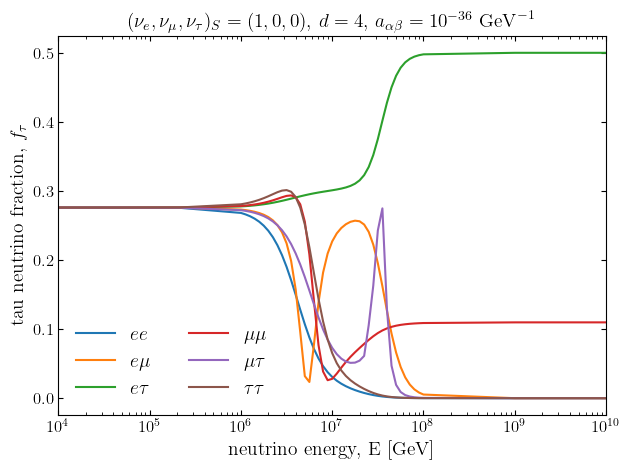

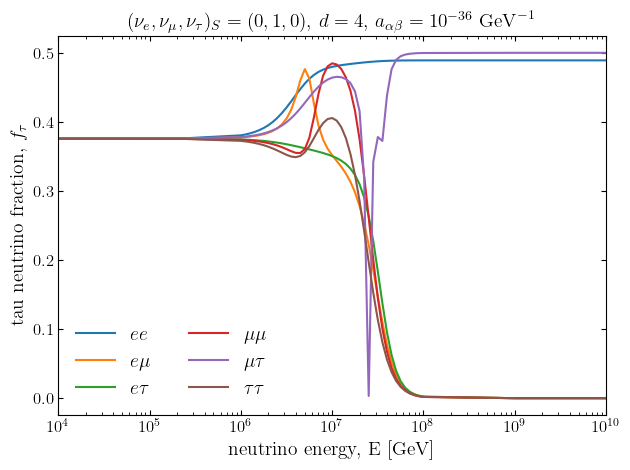

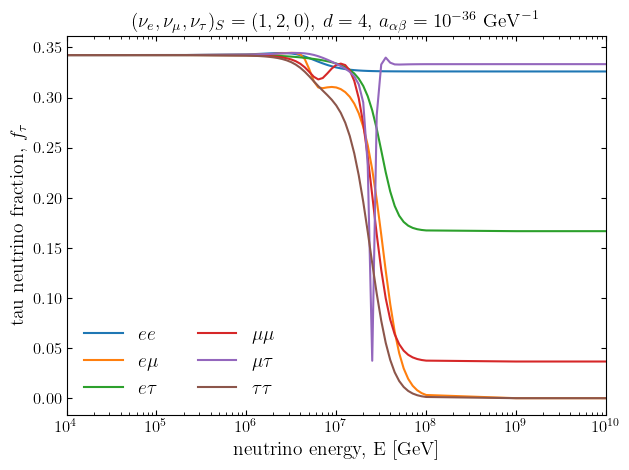

In [455]:
d=4
for src_ratio in [[1,0,0],[0,1,0],[1,2,0]]:
    flavtrack = {}
    srctext = ''.join(f"{x}" for x in src_ratio)

    for alpha in range(3):
        for beta in range(alpha,3):
            LIVmatrix = np.zeros((3, 3), dtype=complex)
            LIVmatrix[alpha, beta] = 1e-36  # GeV^{-2}
            flavtracktemp = []

            Erange = np.concatenate(
                [np.logspace(4,6,3,endpoint=False), 
                 np.logspace(6,8,40,endpoint=False), 
                 np.logspace(8,10,3)])

            for E in Erange:
                flavtracktemp.append([E,
                                  flavor_fraction(E, dm21, dm31, 
                                                  theta12, theta23, theta13, delta,
                                                  theta, phi, d=d, 
                                                  a_eff={(0,0):LIVmatrix}, 
                                                  c_eff={(0,0):LIVmatrix},
                                                  src_ratio=src_ratio, flavor='tau')] ) 

            flavtrack[alpha,beta] = flavtracktemp

    plt.figure()
    flavlabel = [r'$e$',r'$\mu$',r'$\tau$']
    for (alpha, beta), en_taufrac in flavtrack.items():
        en_taufrac = np.array(en_taufrac)
        en = en_taufrac[:,0]
        taufrac = en_taufrac[:,1]
        plt.plot(en, taufrac, label=f"{flavlabel[alpha]}{flavlabel[beta]}")

    plt.xscale("log")   # since your c is like 1e-75 ...
    plt.xlabel("neutrino energy, E [GeV]", fontsize=14)
    plt.ylabel(r"tau neutrino fraction, $f_\tau$", fontsize=14)
    plt.title(fr"$(\nu_e,\nu_\mu,\nu_\tau)_S={tuple(src_ratio)}$, $d={d}$, $a_{{\alpha\beta}}=10^{{-36}}\ \mathrm{{GeV}}^{{-1}}$", 
              fontsize=14)
    plt.legend(frameon=False, ncol=2, loc="lower left", fontsize=14)
    plt.xlim(Erange[0],Erange[-1])
#     plt.grid(True)
    plt.tick_params(top=True, bottom=True, left=True, right=True,
                    which='both', direction='in')
    plt.tick_params(axis='both', which='major', labelsize=12)  # major ticks
    plt.tick_params(axis='both', which='minor', labelsize=8)  # minor ticks

    plt.tight_layout()
    plt.savefig(f'figures/taufrac_E_dim{d}_src{srctext}.pdf',dpi=300)
    plt.show()

In [19]:
# Integration limits in eV
E_min = 1e15      # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV
year = 365*24*3600

def tau_count(d=0, a_eff=None, c_eff=None, src_ratio=[1,2,0]):
    # Define the integrand_flux_area
    def integrand_flux_area(E, d, a_eff, c_eff, src_ratio):
        EnuGeV = E * 1e-9
        # flux = rate/E^2 = 1/(GeV cm^2 s sr)
        # area = cm^2 sr
        # flux * area = GeV^-1 s^-1
        unit_refiner = (1/EnuGeV**2 ) * 1e-9 
        #factor explanaton: 1/E^2, 1/GeV to 1/eV

        dm21, dm31 = np.array([7.49e-5, 2.534e-3])*1e-18
        theta = np.pi / 3 # polar angle
        phi = np.pi / 4   # azimuthal angle
        theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                                      np.arcsin(np.sqrt(0.02225)), 
                                      np.arcsin(np.sqrt(0.572))]

        delta = 197*np.pi/180

        ftau_fraction = flavor_fraction(E, dm21, dm31, 
                  theta12, theta23, theta13, delta,
                  theta, phi, d, a_eff, c_eff,
                  src_ratio, flavor='tau')
        
        return flux_interp(E) * ftau_fraction * poemma_area_interp(E) * unit_refiner    # 1/(s)

    # Perform the integral
    result, err = quad(integrand_flux_area, E_min, E_max, 
                       args=(d, a_eff, c_eff, src_ratio), limit=500, epsrel=1e-4)#, epsabs=0, epsrel=1e-4)

    # tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
    # full 360 degree i.e. 2pi azimuth # hence no factor 30/360
    # 0.2 for duty cycle, 1/3 for tau flavor
    return result * 5*year*0.20

In [20]:
tempfractau = flavor_fraction(1e5, dm21, dm31, 
                  theta12, theta23, theta13, delta,
                  theta, phi,flavor='tau')


tau_count(), 13.083310417281368*3*tempfractau

(13.447556663271548, 13.439666755467197)

In [21]:
a_eff

{(0,
  0): array([[0.00000000e+00+0.j, 1.81704155e+08+0.j, 0.00000000e+00+0.j],
        [0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
        [0.00000000e+00+0.j, 0.00000000e+00+0.j, 1.00000000e+09+0.j]])}

In [22]:
tau_count(src_ratio=[1,1,0]),tau_count(5,
                                       a_eff={(0,
  0): np.array([[0.00000000e+00+0.j, 4.20066945e+28+0.j, 1.00000000e+29+0.j],
        [0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
        [0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j]])},
                                       c_eff=None,
                                       src_ratio=[1,1,0])

(12.794585776613587, 12.100872940552486)

In [26]:
H_LIV_paper(E, theta, phi, d=3, a_eff=a_eff, c_eff=c_eff)

array([[0.00000000e+00+0.j, 1.81704155e+08+0.j, 0.00000000e+00+0.j],
       [1.81704155e+08+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
       [0.00000000e+00+0.j, 0.00000000e+00+0.j, 2.00000000e+09+0.j]])

In [27]:
from scipy.optimize import fsolve

def tau_c_temp(d,cx,src_ratio):
    temptau = tau_count(d,
                        a_eff={(0,0): cx * np.array([[0.00000000e+00+0.j, 4.20066945e-28+0.j, 1.00000000e-29+0.j],
                                                     [0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
                                                     [0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j]])},
                        c_eff=None,
                        src_ratio=src_ratio)
    return temptau

def equation(cx, d=3, src_ratio=[1,2,0]):
    cx = float(cx)
    target = chi2.ppf(0.95, 2)
    a_eff={}
    a_eff[(0,0)] =  np.array([[0.00000000e+00+0.j, cx*4.20066945e-28+0.j, cx*1.00000000e-29+0.j],
                                 [0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j],
                                 [0.00000000e+00+0.j, 0.00000000e+00+0.j, 0.00000000e+00+0.j]])
    c_eff=None

    H0 = H0_flavor(E, dm21, dm31, theta12, theta23, theta13, delta)
    HLIV = H_LIV_paper(E, theta, phi, d, a_eff, c_eff)
    Htot = H0 + HLIV
    A = Htot / np.max(np.abs(Htot)) 
#     print(a_eff, c_eff, cx)#A, H0,HLIV, a_eff, c_eff, cx, np.max(np.abs(Htot)) )#, Htot, np.max(np.abs(Htot)) )
#     print (chisq(tau_c_temp(d,cx,src_ratio), tau_c_temp(d,0,src_ratio)), target)
    print(d,cx,src_ratio,tau_c_temp(d,cx,src_ratio), tau_c_temp(d,0,src_ratio))
    return chisq(tau_c_temp(d,cx,src_ratio), tau_c_temp(d,0,src_ratio)) - target

# """
guesses = np.logspace(np.log10(1e-5), np.log10(1e10), 20)
# print(f"guesses={guesses}")
def eq_c(c):
    d = 5               # example value
    src_ratio = [1,2,0]       # example value

    val = equation(c, d, src_ratio)
    return val# np.sum(val) 

# print(eq_c(2))
roots = []

for g in guesses:
#     root = fsolve(eq_c, g)[0]
    print(f"g={g}, rest= ={eq_c(g)}")
#     roots.append(root)

roots = np.unique(np.round(roots, 6))
print("All solutions:", roots)
# # """

5 1e-05 [1, 2, 0] 0.02602522082934385 13.447556663271548
g=1e-05, rest= =135.19233289789435
5 6.158482110660267e-05 [1, 2, 0] 0.026025220829343866 13.447556663271548
g=6.158482110660267e-05, rest= =135.19233289789432
5 0.000379269019073225 [1, 2, 0] 0.02602522082934385 13.447556663271548
g=0.000379269019073225, rest= =135.19233289789435
5 0.002335721469090121 [1, 2, 0] 0.02602522082934386 13.447556663271548
g=0.002335721469090121, rest= =135.19233289789432
5 0.01438449888287663 [1, 2, 0] 0.026025220829343866 13.447556663271548
g=0.01438449888287663, rest= =135.19233289789432
5 0.08858667904100832 [1, 2, 0] 0.02602522082934385 13.447556663271548
g=0.08858667904100832, rest= =135.19233289789435
5 0.5455594781168515 [1, 2, 0] 0.02602522082934385 13.447556663271548
g=0.5455594781168515, rest= =135.19233289789435
5 3.359818286283781 [1, 2, 0] 0.026025220829343856 13.447556663271548
g=3.359818286283781, rest= =135.19233289789435
5 20.6913808111479 [1, 2, 0] 0.02602522082934386 13.44755666327

[14.753498436587487, 14.753498436587492, 14.753498436587487, 14.753498436587492, 14.753498436587487, 14.753498436587439, 14.753498436586913, 14.753498436581253, 14.753498436519985, 14.753498435856578, 14.753498428674286, 14.753498350910641, 14.753497508358704, 14.753488310068906, 14.753379974402822, 14.751509157949176, 14.749207080954008, 14.829796411029058, 15.098802593614113, 15.719658060819889, 16.7834747915422, 17.946655306899927, 18.85993312194554, 19.32729425273799, 19.5218952782832, 19.60821710531701, 19.628513932392295, 19.636498198651964, 19.63648928383222, 19.636486705803648]


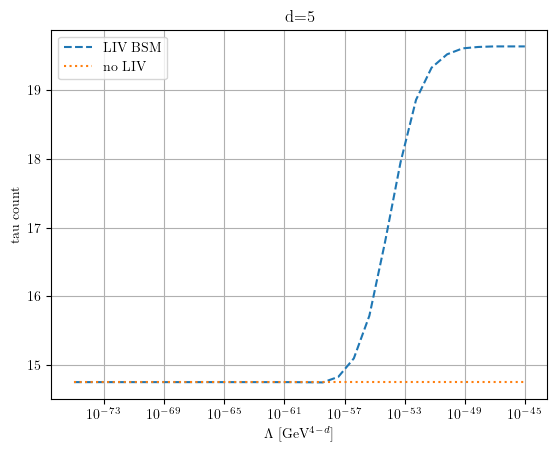

In [161]:
# for sol in guesses:
#     src_ratio = [1,2,0]
#     print(sol, tau_c_temp(5,sol,src_ratio))

d=5
guesses = np.logspace(np.log10(1e-75), np.log10(1e-45), 30)
src_ratio = [0,1,0]

# for k in range(1):
tau_vals = []
tau_vals_std = []
for sol in guesses:
#         solrand12 = np.random.rand(2)
#         sol1, sol2 = solrand12 * sol
    sol1 = sol*1j
    sol2=0
    tau_vals.append(tau_count(d,a_eff={(0,0): np.array([[0.00000000e+00+0.j, 
                                     0, sol2*1.00000000e-23+0.j],
                                    [0.00000000e+00+0.j, 0, 0.00000000e+00+0.j],
                                    [0, sol1*4.20066945e-23
                                     +0.j, 0.00000000e+00+0.j]])},
          c_eff=None,
          src_ratio=src_ratio) )
    tau_vals_std.append(tau_count(src_ratio=src_ratio))

print(tau_vals)

plt.plot(guesses, tau_vals,linestyle='--', label='LIV BSM')
plt.plot(guesses, tau_vals_std,linestyle=':', label='no LIV')
plt.xlabel(r"$\Lambda$ [GeV$^{4-d}$]")
plt.ylabel("tau count")
plt.title(f"d={d}")
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

In [243]:
tau_count

<function __main__.tau_count(d=0, a_eff=None, c_eff=None, src_ratio=[1, 2, 0])>

In [261]:
d=4
guesses = np.logspace(np.log10(1e-75), np.log10(1e-15), 15)
tau_count_track = {}

for src_ratio in [[1,0,0],[0,1,0],[1,2,0]]:
    srctext = ''.join(f"{x}" for x in src_ratio)
    tau_count_track[srctext] = {}

    for alpha in range(3):
        for beta in range(alpha,3):
            
            tau_vals = []
            tau_vals_std = []
            for sol in guesses:
                LIVmatrix = np.zeros((3, 3), dtype=complex)
                LIVmatrix[alpha, beta] = sol  # GeV^{-n}
                tau_vals.append([sol,
                                 tau_count(d=d,
                                           a_eff={(0,0):LIVmatrix}, 
                                           c_eff={(0,0):LIVmatrix},
                                           src_ratio=src_ratio)
                                ])
                tau_vals_std.append([sol,tau_count(src_ratio=src_ratio)])

            tau_vals = np.array(tau_vals)
            tau_vals_std = np.array(tau_vals_std)
            tau_count_track[srctext][alpha,beta] = {'LIV':tau_vals,
                                    'std':tau_vals_std}


/var/folders/nf/tkjc_md55g704s30wfmx4wzh0000gn/T/ipykernel_7829/3157548063.py:33: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, err = quad(integrand_flux_area, E_min, E_max,


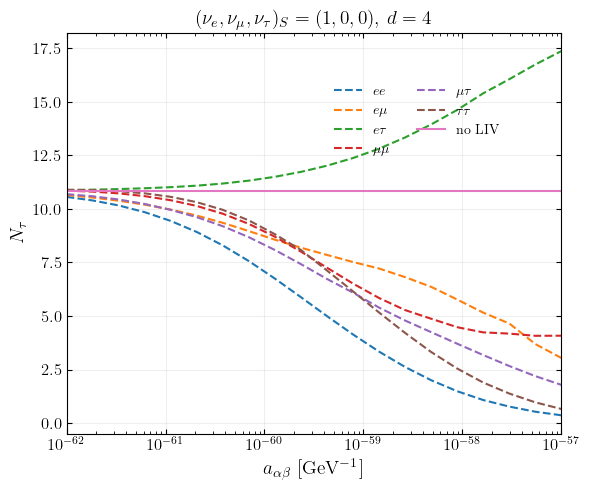

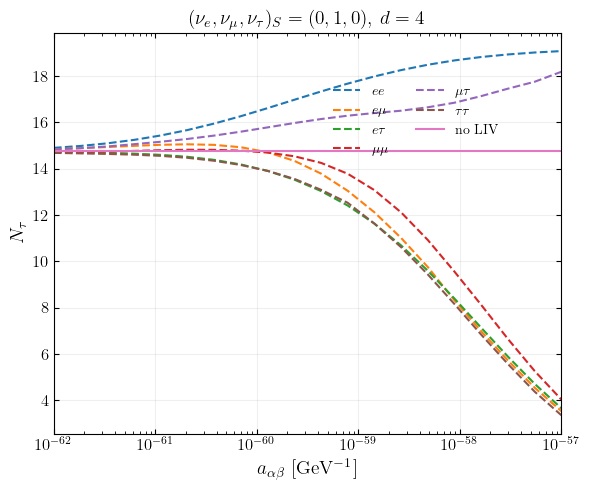

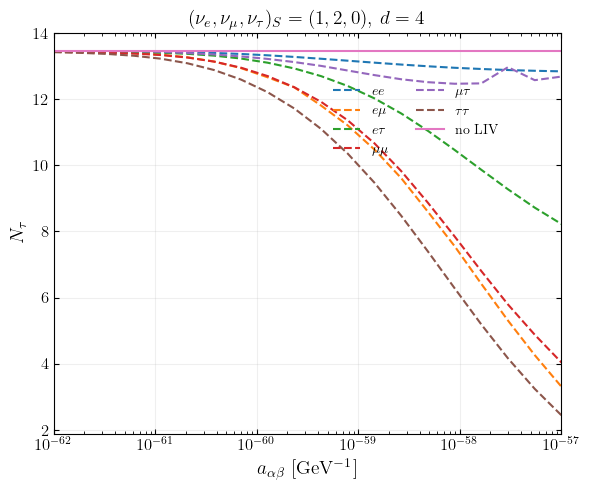

In [456]:
for src_ratio in [[1,0,0],[0,1,0],[1,2,0]]:
    srctext = ''.join(f"{x}" for x in src_ratio)

    plt.figure(figsize=(6,5))

    for (alpha, beta), data in tau_count_track[srctext].items():

        tau_vals = data['LIV']   # shape (N,2)
        sol = tau_vals[:,0]
        tau = tau_vals[:,1]

        plt.plot(sol, tau, linestyle='--', label=f"{flavlabel[alpha]}{flavlabel[beta]}")
    
    plt.plot(sol, data['std'][:,1], linestyle='-', label=f"no LIV")
    plt.legend(frameon=False, ncol=2, loc='upper right', bbox_to_anchor=(0.9,0.9))

    plt.xscale("log")
    plt.xlabel(r"$a_{\alpha\beta}$ [GeV$^{-1}$]", fontsize=14)
    plt.ylabel(r"$N_\tau$", fontsize=14)
    plt.title(fr"$(\nu_e,\nu_\mu,\nu_\tau)_S={tuple(src_ratio)}$, $d={d}$", 
              fontsize=14)
    plt.xlim(sol[0],sol[-1])
    plt.tick_params(top=True, bottom=True, left=True, right=True,
                    which='both', direction='in')
    plt.tick_params(axis='both', which='major', labelsize=12)  # major ticks
    plt.tick_params(axis='both', which='minor', labelsize=8)  # minor ticks
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'figures/taucount_LIVparam_dim{d}_src{srctext}.pdf',dpi=300)
    plt.show()

In [245]:
chisq(1.96364867e+01, 14.753498436587487)

1.3296556835023612

## chi2

In [375]:
d=4
guesses = np.logspace(np.log10(1e-62), np.log10(1e-57), 20)
tau_count_track = {}

for src_ratio in [[1,0,0],[0,1,0],[1,2,0]]:
    srctext = ''.join(f"{x}" for x in src_ratio)
    tau_count_track[srctext] = {}

    for alpha in range(3):
        for beta in range(alpha,3):
            
            tau_vals = []
            tau_vals_std = []
            for sol in guesses:
                LIVmatrix = np.zeros((3, 3), dtype=complex)
                LIVmatrix[alpha, beta] = sol  # GeV^{-n}
                tau_vals.append([sol,
                                 tau_count(d=d,
                                           a_eff={(0,0):LIVmatrix}, 
                                           c_eff={(0,0):LIVmatrix},
                                           src_ratio=src_ratio)
                                ])
                tau_vals_std.append([sol,tau_count(src_ratio=src_ratio)])

            tau_vals = np.array(tau_vals)
            tau_vals_std = np.array(tau_vals_std)
            tau_count_track[srctext][alpha,beta] = {'LIV':tau_vals,
                                    'std':tau_vals_std}


/var/folders/nf/tkjc_md55g704s30wfmx4wzh0000gn/T/ipykernel_7829/3157548063.py:33: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, err = quad(integrand_flux_area, E_min, E_max,


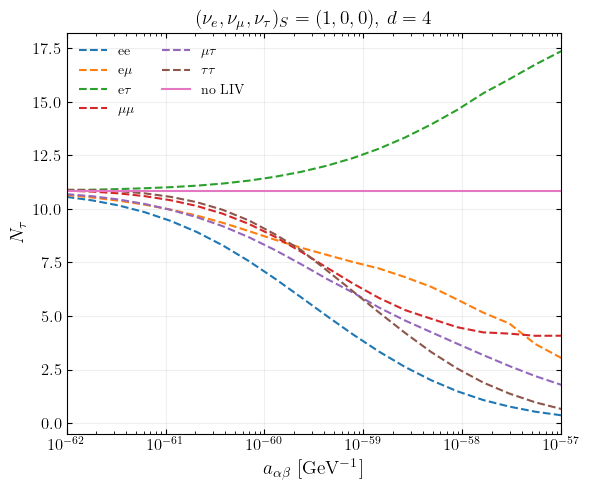

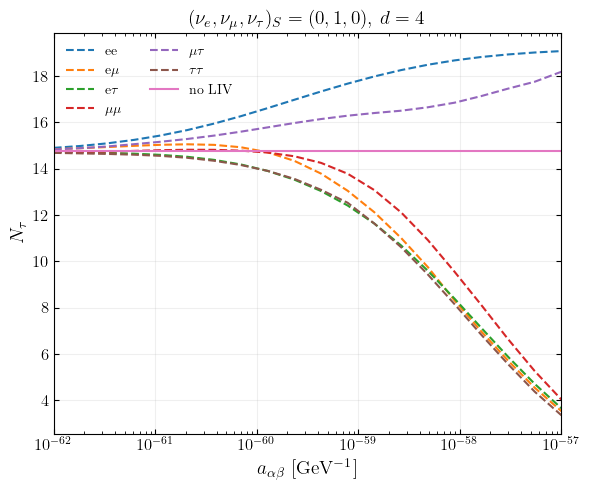

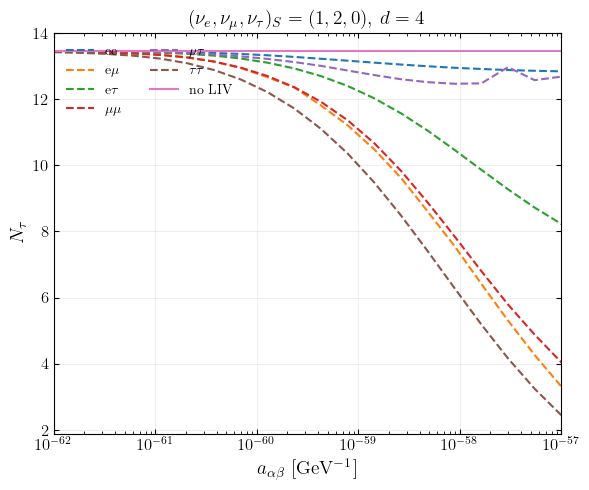

In [376]:
for src_ratio in [[1,0,0],[0,1,0],[1,2,0]]:
    srctext = ''.join(f"{x}" for x in src_ratio)

    plt.figure(figsize=(6,5))

    for (alpha, beta), data in tau_count_track[srctext].items():

        tau_vals = data['LIV']   # shape (N,2)
        sol = tau_vals[:,0]
        tau = tau_vals[:,1]

        plt.plot(sol, tau, linestyle='--', label=f"{flavlabel[alpha]}{flavlabel[beta]}")
    
    plt.plot(sol, data['std'][:,1], linestyle='-', label=f"no LIV")
    plt.legend(frameon=False, ncol=2, loc='upper left')#, bbox_to_anchor=(0.9,0.9))

    plt.xscale("log")
    plt.xlabel(r"$a_{\alpha\beta}$ [GeV$^{-1}$]", fontsize=14)
    plt.ylabel(r"$N_\tau$", fontsize=14)
    plt.title(fr"$(\nu_e,\nu_\mu,\nu_\tau)_S={tuple(src_ratio)}$, $d={d}$", 
              fontsize=14)
    plt.xlim(sol[0],sol[-1])
    plt.tick_params(top=True, bottom=True, left=True, right=True,
                    which='both', direction='in')
    plt.tick_params(axis='both', which='major', labelsize=12)  # major ticks
    plt.tick_params(axis='both', which='minor', labelsize=8)  # minor ticks
    plt.grid(alpha=0.2)
    plt.tight_layout()
#     plt.savefig(f'figures/taucount_LIVparam_dim{d}_src{srctext}.pdf',dpi=300)
    plt.show()

120


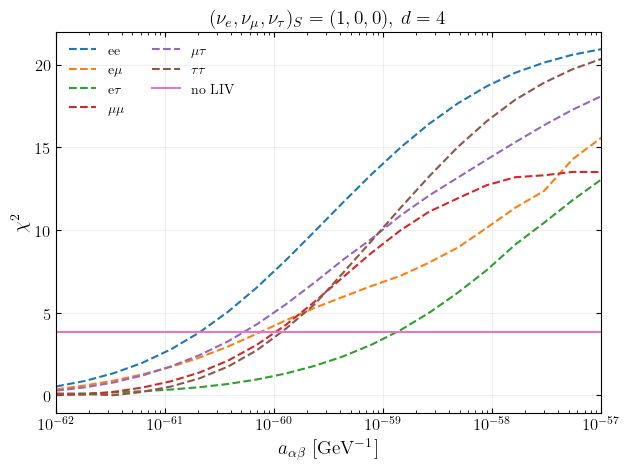

100


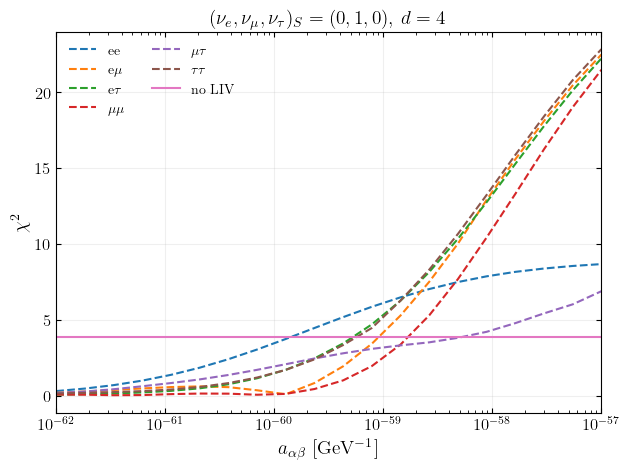

010


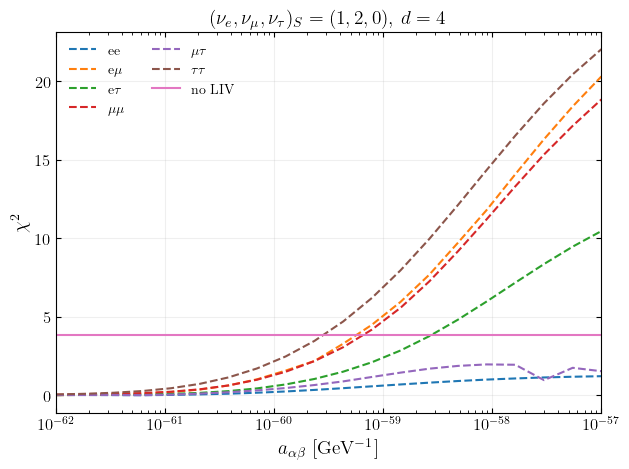

In [425]:
for src_ratio in [[1,0,0],[0,1,0],[1,2,0]]:
    print(srctext)
    srctext = ''.join(f"{x}" for x in src_ratio)
    for (alpha, beta), data in tau_count_track[srctext].items():
        tau_vals = data['LIV']   # shape (N,2)
        c_vals = tau_vals[:,0]
        NBSM_vals = tau_vals[:,1]
        N0 = tau_count(src_ratio=src_ratio)
        target = chi2.ppf(0.95, 1)

        # compute diff array
        diff_vals = np.abs(NBSM_vals - N0)

        # mask out zero-diff points
        mask = diff_vals != 0

        c_vals_f = c_vals[mask]
        diff_vals_f = diff_vals[mask]

        # build interpolator on filtered data
        diff_of_c = interp1d(c_vals_f, diff_vals_f, 
                             kind='cubic', fill_value="extrapolate")
        
        chi_vals = np.array([chisq(x, 0) for x in diff_vals_f])
        idx = np.argmin(np.abs(chi_vals - target))
        c_solution = c_vals_f[idx]
#         print(chisq(diff_of_c(c_solution), 0),target)

        plt.plot(c_vals_f, chi_vals, linestyle='--', label=f"{flavlabel[alpha]}{flavlabel[beta]}")
    
    plt.plot(c_vals_f, [target for x in chi_vals], linestyle='-', label=f"no LIV")
    plt.legend(frameon=False, ncol=2, loc='upper left')#, bbox_to_anchor=(0.9,0.9))

    plt.xscale("log")
    plt.xlabel(r"$a_{\alpha\beta}$ [GeV$^{-1}$]", fontsize=14)
    plt.ylabel(r"$\chi ^2$", fontsize=14)
    plt.title(fr"$(\nu_e,\nu_\mu,\nu_\tau)_S={tuple(src_ratio)}$, $d={d}$", 
              fontsize=14)
    plt.xlim(c_vals_f[0],c_vals_f[-1])
    plt.tick_params(top=True, bottom=True, left=True, right=True,
                    which='both', direction='in')
    plt.tick_params(axis='both', which='major', labelsize=12)  # major ticks
    plt.tick_params(axis='both', which='minor', labelsize=8)  # minor ticks
    plt.grid(alpha=0.2)
    plt.tight_layout()
#     plt.savefig(f'figures/chisq_LIVparam_dim{d}_src{srctext}.pdf',dpi=300)
    plt.show()

In [427]:
LIVparam = {}
LIVparam[d]={}

for src_ratio in [[1,0,0],[0,1,0],[1,2,0]]:
    srctext = ''.join(f"{x}" for x in src_ratio)
    print(srctext)
    LIVparam[d][srctext] = {}
    for (alpha, beta), data in tau_count_track[srctext].items():
        print(f"{alpha, beta}")
        tau_vals = data['LIV']   # shape (N,2)
        c_vals = tau_vals[:,0]
        NBSM_vals = tau_vals[:,1]
        N0 = tau_count(src_ratio=src_ratio)
        target = chi2.ppf(0.95, 1)

        # compute diff array
        diff_vals = np.abs(NBSM_vals - N0)

        # mask out zero-diff points
        mask = diff_vals != 0

        c_vals_f = c_vals[mask]
        diff_vals_f = diff_vals[mask]

        # build interpolator on filtered data
        diff_of_c = interp1d(c_vals_f, diff_vals_f, 
                             kind='cubic', fill_value="extrapolate")
        
#         print(chisq(diff_of_c(2.3256822905487024e-57), 0))
        def makezero(c):
            return chisq(diff_of_c(c), 0) - target

#         ### vanilla 
#         chi_vals = np.array([chisq(x, 0) for x in diff_vals_f])
#         idx = np.argmin(np.abs(chi_vals - target))
#         c_solution = c_vals_f[idx]
#         print(f"{alpha, beta}, c =", c_solution,
#               np.round(makezero(c_solution),3))

#         ### brentq, needs +,- 
#         c_min = c_vals_f.min()
#         c_max = c_vals_f.max()
#         c_solution = brentq(makezero, c_min, c_max)
        
        ### fsolve, needs good guess 
        c_solution = 0
        for c_guess in [1e-57, 1e-58, 1e-59, 1e-60, 1e-61, 1e-62]:
            csol = fsolve(makezero, c_guess)[0]
#             print(makezero(c_solution), makezero(csol))
            if np.abs(makezero(csol))<0.001 and csol>0:
                c_solution = csol
#             print(makezero(csol),csol,c_solution)

        print(f"{alpha, beta}, c =", c_solution,
          np.round(makezero(c_solution),4))

        LIVparam[d][srctext][f"{alpha,beta}"] = c_solution

#         print("NBSM =", NBSM_of_c(c_solution))

100
(0, 0)
(0, 0), c = 2.0879052202234244e-61 0.0
(0, 1)
(0, 1), c = 7.511456934282977e-61 -0.0
(0, 2)
(0, 2), c = 1.3369811171733836e-59 -0.0
(1, 1)
(1, 1), c = 1.0403601973306026e-60 -0.0
(1, 2)
(1, 2), c = 5.332316509897105e-61 0.0
(2, 2)
(2, 2), c = 1.1715219373951271e-60 -0.0
010
(0, 0)
(0, 0), c = 1.4044941577473193e-60 0.0
(0, 1)
(0, 1), c = 9.03816547162045e-60 -0.0
(0, 2)
(0, 2), c = 5.297800876702421e-60 0.0
(1, 1)
(1, 1), c = 1.7012218607606496e-59 -0.0
(1, 2)
(1, 2), c = 5.168904328888418e-59 0.0
(2, 2)
(2, 2), c = 5.730070892762852e-60 -0.0
120
(0, 0)
(0, 0), c = 2.3256822905487024e-57 -0.0
(0, 1)
(0, 1), c = 5.585147918953504e-60 0.0
(0, 2)
(0, 2), c = 2.777409713328784e-59 0.0
(1, 1)
(1, 1), c = 6.642157499456287e-60 0.0
(1, 2)
(1, 2), c = 0 -3.8338
(2, 2)
(2, 2), c = 2.857467751962597e-60 -0.0


In [490]:
[np.log10(y_top)]

/var/folders/nf/tkjc_md55g704s30wfmx4wzh0000gn/T/ipykernel_7829/2563881905.py:1: RuntimeWarning: invalid value encountered in log10
  [np.log10(y_top)]


[nan]

6 (6,)
6 (6,)
6 (6,)


/var/folders/nf/tkjc_md55g704s30wfmx4wzh0000gn/T/ipykernel_7829/3110920456.py:25: RuntimeWarning: divide by zero encountered in log10
  print(len(np.log10(vals[:, j])), np.shape(np.log10(vals[:, j])))
/var/folders/nf/tkjc_md55g704s30wfmx4wzh0000gn/T/ipykernel_7829/3110920456.py:26: RuntimeWarning: divide by zero encountered in log10
  plt.bar(x + j*width, np.log10(vals[:, j]) - np.log10(y_top),


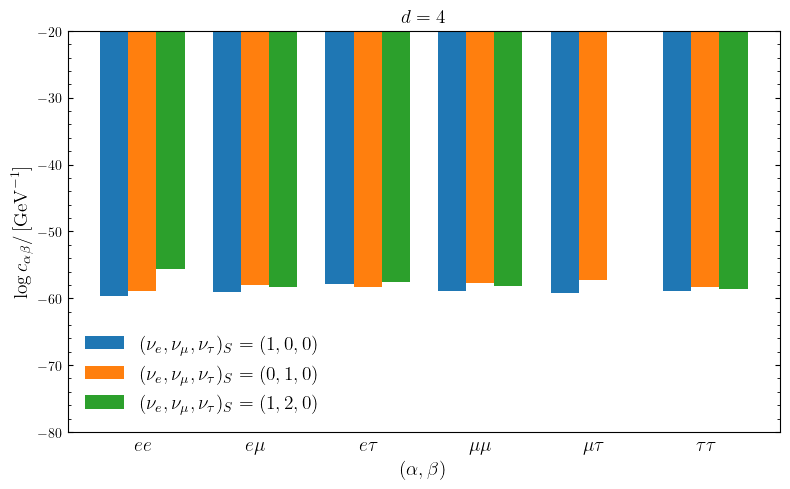

In [501]:
d = 4
src_ratio_all = [[1,0,0],[0,1,0],[1,2,0]]
srctexts = ["100", "010", "120"]
colors = ["tab:blue", "tab:orange", "tab:green"]

# get alpha,beta keys from one entry
alphabeta_keys = list(LIVparam[d][srctexts[0]].keys())  # 6 of them

# prepare data matrix: rows = alpha,beta, cols = srctext
vals = np.zeros((len(alphabeta_keys), len(srctexts)))

for i, ab in enumerate(alphabeta_keys):
    for j, sr in enumerate(srctexts):
        vals[i, j] = LIVparam[d][sr][ab]

# bar positions
x = np.arange(len(alphabeta_keys))
width = 0.25

plt.figure(figsize=(8,5))

y_top = (1e-1)

for j in range(len(srctexts)):
    print(len(np.log10(vals[:, j])), np.shape(np.log10(vals[:, j])))
    plt.bar(x + j*width, np.log10(vals[:, j]) - np.log10(y_top),
            color=colors[j], width=width)

# x-ticks: alpha,beta labels
plt.xticks(x + width, 
          [f"{flavlabel[k[0]]}{flavlabel[k[1]]}"
           for k in (ast.literal_eval(x) for x in alphabeta_keys)],
          fontsize=14)

# plt.yscale("log")
# plt.ylim(1e-40, 1e-80)
plt.ylim(np.log10(1e-20), -80)
# plt.ylim(np.log10(y_top), -90)


plt.gca().invert_yaxis()

plt.ylabel(r"$\log{c_{\alpha\beta}/\,[\mathrm{GeV}^{-1}]}$", fontsize=14)
plt.xlabel(r"$(\alpha,\beta)$", fontsize=14)
plt.title(rf"$d={d}$", fontsize=14)

# legend (srctext)
src_legend = [fr"$(\nu_e,\nu_\mu,\nu_\tau)_S={tuple(src_ratio_all[0])}$", 
              fr"$(\nu_e,\nu_\mu,\nu_\tau)_S={tuple(src_ratio_all[1])}$", 
              fr"$(\nu_e,\nu_\mu,\nu_\tau)_S={tuple(src_ratio_all[2])}$"]

plt.legend(src_legend, frameon=False, fontsize=14)

plt.tick_params(top=False, bottom=False, right=True,
                direction="in", which="both")
plt.minorticks_on()

plt.tight_layout()
plt.savefig("figures/param_dim4.pdf", dpi=300)
plt.show()